In [1]:
# STEP 1 : Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
#Extracting the dataset
import zipfile
import os

zip_path = r"C:\Users\ashme\Downloads\archive.zip"
extract_path = r"C:\Users\ashme\Downloads\HealthcareFraudDataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

for file in os.listdir(r"C:\Users\ashme\Downloads\HealthcareFraudDataset"):
    print(file)

Test-1542969243754.csv
Test_Beneficiarydata-1542969243754.csv
Test_Inpatientdata-1542969243754.csv
Test_Outpatientdata-1542969243754.csv
Train-1542865627584.csv
Train_Beneficiarydata-1542865627584.csv
Train_Inpatientdata-1542865627584.csv
Train_Outpatientdata-1542865627584.csv


In [4]:
#Loading the dataset
import pandas as pd

path = r"C:\Users\ashme\Downloads\HealthcareFraudDataset"

train = pd.read_csv(path + r"\Train-1542865627584.csv")
beneficiary = pd.read_csv(path + r"\Train_Beneficiarydata-1542865627584.csv")
inpatient = pd.read_csv(path + r"\Train_Inpatientdata-1542865627584.csv")
outpatient = pd.read_csv(path + r"\Train_Outpatientdata-1542865627584.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
# Missing Value Summary Function

import pandas as pd

def missing_table(df):

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    percent = (missing / len(df)) * 100

    table = pd.DataFrame({
        "Missing Values": missing,
        "Percentage (%)": percent.round(2)
    })

    table = table.sort_values(by="Percentage (%)", ascending=False)

    return table

In [6]:
print("TRAIN")
display(missing_table(train))

print("BENEFICIARY")
display(missing_table(beneficiary))

print("INPATIENT")
display(missing_table(inpatient))

print("OUTPATIENT")
display(missing_table(outpatient))

TRAIN


,Missing Values,Percentage (%)


BENEFICIARY


,Missing Values,Percentage (%)
DOD,137135,98.97


INPATIENT


,Missing Values,Percentage (%)
ClmProcedureCode_6,40474,100.00
ClmProcedureCode_5,40465,99.98
ClmProcedureCode_4,40358,99.71
ClmProcedureCode_3,39509,97.62
ClmDiagnosisCode_10,36547,90.30
OtherPhysician,35784,88.41
ClmProcedureCode_2,35020,86.52
ClmProcedureCode_1,17326,42.81
OperatingPhysician,16644,41.12
ClmDiagnosisCode_9,13497,33.35


OUTPATIENT


,Missing Values,Percentage (%)
ClmProcedureCode_6,517737,100.00
ClmProcedureCode_5,517737,100.00
ClmProcedureCode_4,517735,100.00
ClmProcedureCode_3,517733,100.00
ClmProcedureCode_2,517701,99.99
ClmProcedureCode_1,517575,99.97
ClmDiagnosisCode_10,516654,99.79
ClmDiagnosisCode_9,502899,97.13
ClmDiagnosisCode_8,494825,95.57
ClmDiagnosisCode_7,484776,93.63


In [7]:
#dataset size
print("="*60)
print("DATASET SHAPES")
print("="*60)

datasets = {
    "Provider": train,
    "Beneficiary": beneficiary,
    "Inpatient": inpatient,
    "Outpatient": outpatient
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows × {df.shape[1]} columns")

DATASET SHAPES
Provider: 5410 rows × 2 columns
Beneficiary: 138556 rows × 25 columns
Inpatient: 40474 rows × 30 columns
Outpatient: 517737 rows × 27 columns


In [8]:
#feature type
print("="*60)
print("FEATURE TYPES")
print("="*60)

for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print(df.dtypes.value_counts())

FEATURE TYPES

Provider Dataset
object    2
Name: count, dtype: int64

Beneficiary Dataset
int64     21
object     4
Name: count, dtype: int64

Inpatient Dataset
object     22
float64     7
int64       1
Name: count, dtype: int64

Outpatient Dataset
object     19
float64     6
int64       2
Name: count, dtype: int64


In [9]:
#descriptive stats
print("Provider Dataset")
display(train.describe(include='all'))

print("Beneficiary Dataset")
display(beneficiary.describe(include='all'))

Provider Dataset


,Provider,PotentialFraud
count,5410,5410
unique,5410,2
top,PRV51001,No
freq,1,4904


Beneficiary Dataset


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
count,138556,138556,1421,138556.000000,138556.000000,138556,138556.000000,138556.000000,138556.000000,138556.000000,...,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000
unique,138556,900,11,NaN,NaN,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,BENE11001,1939-10-01,2009-12-01,NaN,NaN,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,540,182,NaN,NaN,118978,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.570932,1.254511,NaN,25.666734,374.424745,11.907727,11.910145,...,1.644476,1.398142,1.324143,1.725317,1.743180,1.920942,3660.346502,399.847296,1298.219348,377.718258
std,NaN,NaN,NaN,0.494945,0.717007,NaN,15.223443,266.277581,1.032332,0.936893,...,0.478674,0.489517,0.468056,0.446356,0.436881,0.269831,9568.621827,956.175202,2493.901134,645.530187
min,NaN,NaN,NaN,1.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-8000.000000,0.000000,-70.000000,0.000000
25%,NaN,NaN,NaN,1.000000,1.000000,NaN,11.000000,141.000000,12.000000,12.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,170.000000,40.000000
50%,NaN,NaN,NaN,2.000000,1.000000,NaN,25.000000,340.000000,12.000000,12.000000,...,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,0.000000,0.000000,570.000000,170.000000
75%,NaN,NaN,NaN,2.000000,1.000000,NaN,39.000000,570.000000,12.000000,12.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2280.000000,1068.000000,1500.000000,460.000000


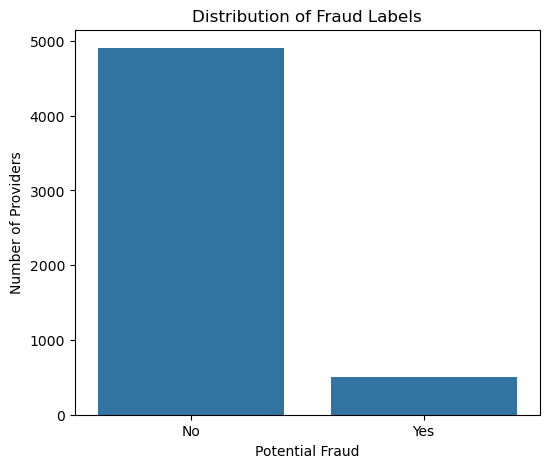

In [10]:
#Distribution of Target Variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    data=train,
    x="PotentialFraud"
)

plt.title("Distribution of Fraud Labels")
plt.xlabel("Potential Fraud")
plt.ylabel("Number of Providers")

plt.show()

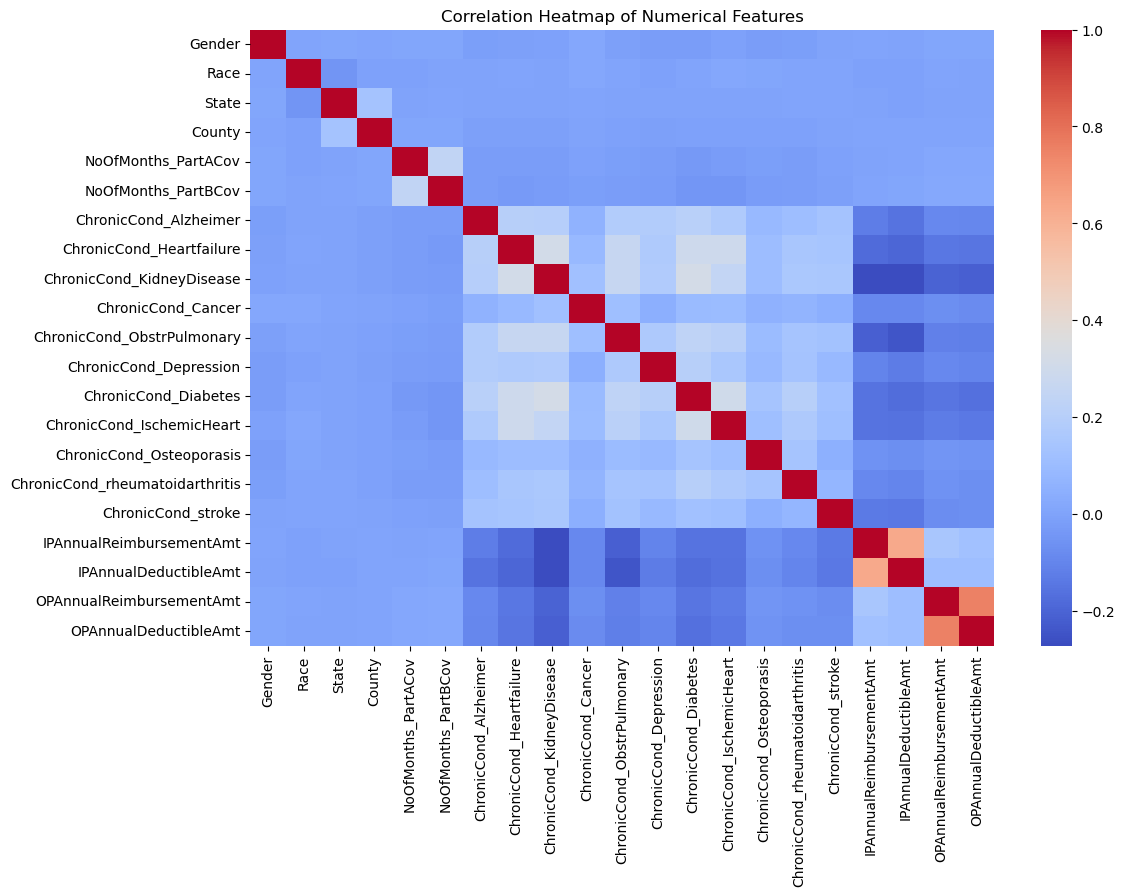

In [11]:
#Correlation Heatmap
import numpy as np

numeric = beneficiary.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

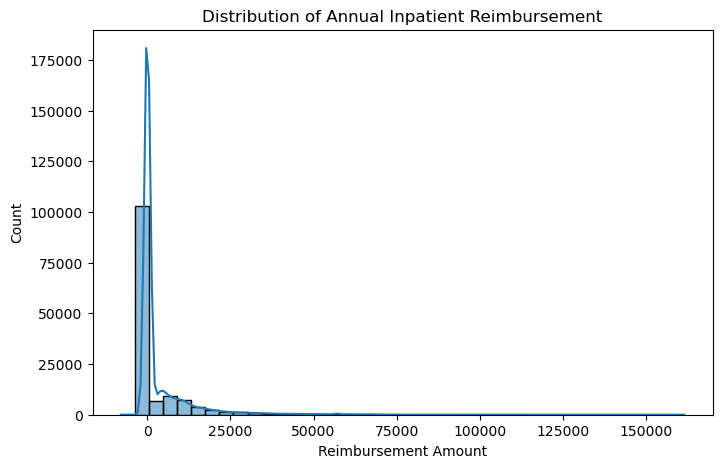

In [12]:
#Distribution Plot
plt.figure(figsize=(8,5))

sns.histplot(
    beneficiary["IPAnnualReimbursementAmt"],
    bins=40,
    kde=True
)

plt.title("Distribution of Annual Inpatient Reimbursement")

plt.xlabel("Reimbursement Amount")

plt.show()

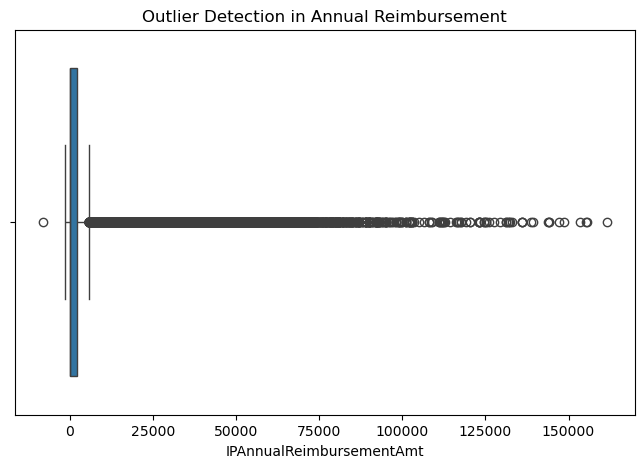

In [13]:
#Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x=beneficiary["IPAnnualReimbursementAmt"]
)

plt.title("Outlier Detection in Annual Reimbursement")

plt.show()